# In Silico `Toxicity` prediction for `Ebola` Antiviral Candidates

This workflow uses `admet_ai` predictions to perform a **rule-based safety triage** of candidate molecules.

The goal is to support **early prioritization**, not to make definitive toxicity claims.

We separate predictions into three categories:

- **Core toxicity risk**: direct safety concerns such as hERG, DILI, AMES, and ClinTox
- **Mechanistic alerts**: stress-response and nuclear-receptor pathway signals
- **ADME / metabolism liabilities**: permeability, transporter, and CYP-related liabilities that may affect developability but do not necessarily imply intrinsic toxicity

In [45]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [61]:
import numpy as np
import pandas as pd
import pubchempy as pcp
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from admet_ai import ADMETModel
from admet_ai.drugbank import get_drugbank
import matplotlib.pyplot as plt
from scipy.stats import percentileofscore

In [47]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
saveDir = os.path.join(resultsDir, "combinedEbolaVirus_bestMACAW/")
DORANETmoleculesDataDir = os.path.join(dataDir, 'DORAnet_molecules/')
ARTresultsDir = os.path.join(dataDir, 'Results/combinedEbolaVirus_bestMACAW/')
os.makedirs(saveDir, exist_ok=True)

## Check toxicty for `buyable` AntiviralsData set

In [48]:
combinedEbolaVirus_wART_Buyable_predicted_all = pd.read_csv(ARTresultsDir + 'Ebola_all_Buyable_AntiVirals_wARTprediction.csv')
max_val = combinedEbolaVirus_wART_Buyable_predicted_all['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_Buyable_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_Buyable_predicted_all

pPotency_prediction range: 4.220 → 6.778


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,4.804306,0.616552,3.595864,6.012748,0.000016,9.710723e-07,0.000254
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,4.842776,0.613032,3.641234,6.044319,0.000014,9.029870e-07,0.000228
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.464808,0.609161,3.270852,5.658764,0.000034,2.193997e-06,0.000536
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,4.862195,0.613532,3.659672,6.064719,0.000014,8.615512e-07,0.000219
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,4.822719,0.611690,3.623807,6.021632,0.000015,9.514116e-07,0.000238
...,...,...,...,...,...,...,...,...
113180,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,5.884116,0.608740,4.690986,7.077247,0.000001,8.370523e-08,0.000020
113181,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,5.744996,0.609386,4.550599,6.939392,0.000002,1.149761e-07,0.000028
113182,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.681098,0.609261,4.486948,6.875249,0.000002,1.332758e-07,0.000033
113183,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,5.670537,0.609623,4.475676,6.865398,0.000002,1.363333e-07,0.000033


### Read predicted ADMET properties for all candidate SMILES

In [49]:
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity = pd.read_csv(ARTresultsDir + 'Ebola_all_Buyable_AntiVirals_wARTprediction_wToxicity.csv')
max_val = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity

pPotency_prediction range: 4.220 → 6.772


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,4.804306,0.616552,3.595864,6.012748,0.000016,9.710723e-07,0.000254,256.331,1.57190,...,87.592090,73.322993,71.074060,35.284994,26.017836,38.542071,57.386584,35.595192,54.711128,19.968980
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,4.842776,0.613032,3.641234,6.044319,0.000014,9.029870e-07,0.000228,237.259,-0.92680,...,97.014347,50.368360,41.295076,47.266382,8.763086,54.439705,19.193486,14.346646,85.963552,27.762699
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.464808,0.609161,3.270852,5.658764,0.000034,2.193997e-06,0.000536,306.410,0.98980,...,79.798371,56.921287,25.668864,74.563784,14.734393,47.150058,20.938348,3.722373,88.367584,94.222567
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,4.862195,0.613532,3.659672,6.064719,0.000014,8.615512e-07,0.000219,279.384,1.82454,...,58.549826,39.976735,28.421869,48.856146,34.703373,62.815045,25.242342,8.181466,86.545173,59.170221
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,4.822719,0.611690,3.623807,6.021632,0.000015,9.514116e-07,0.000238,307.394,0.46540,...,65.529275,69.833269,20.589376,56.184568,17.836371,32.880962,21.170997,5.971307,88.018612,73.206669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62704,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(OC)cc4)cc(C(F...,5.832028,0.608904,4.638575,7.025480,0.000001,9.430177e-08,0.000023,518.517,5.53104,...,65.568050,82.551377,97.557193,96.859248,54.556029,90.151221,94.067468,88.600233,7.987592,42.535867
62705,COC(=O)c1ccc(C(=O)OC)c(NC(=O)c2cc3nc(-c4ccc(Cl...,5.921809,0.608071,4.729990,7.113628,0.000001,7.697901e-08,0.000019,532.862,4.89400,...,67.080264,70.298565,94.804188,97.363319,46.180690,58.123304,94.416440,85.149283,3.218302,22.644436
62706,O=C(Nc1cccc2c1OCO2)c1nn2c(C(F)(F)F)cc(-c3ccc(B...,5.494073,0.609462,4.299527,6.688619,0.000003,2.048239e-07,0.000050,539.695,5.81200,...,66.110896,61.729352,83.404420,96.665374,53.315238,95.036836,94.338891,89.414502,0.426522,26.521908
62707,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.765021,0.609324,4.570745,6.959296,0.000002,1.098256e-07,0.000027,555.003,6.35520,...,71.849554,70.104692,95.308259,96.316402,64.055836,94.998061,94.145017,89.414502,5.195812,73.594416


### Retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [50]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity.columns
]

combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity.shape)
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity.head()

Filtered dataframe shape: (62709, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,4.804306,0.616552,3.595864,6.012748,0.000016,9.710723e-07,0.000254,0.239500,0.016462,...,0.855482,0.945640,0.076049,0.350395,0.290878,0.134904,0.071786,0.002689,0.382473,0.005204
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,4.842776,0.613032,3.641234,6.044319,0.000014,9.029870e-07,0.000228,0.152839,0.008214,...,0.636528,0.914472,0.003674,0.034129,0.375321,0.005663,0.109176,0.002534,0.404691,0.004057
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.464808,0.609161,3.270852,5.658764,0.000034,2.193997e-06,0.000536,0.638718,0.690349,...,0.914802,0.946715,0.091784,0.044804,0.168623,0.005473,0.320181,0.105699,0.264736,0.014986
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,4.862195,0.613532,3.659672,6.064719,0.000014,8.615512e-07,0.000219,0.121497,0.362352,...,0.894814,0.896890,0.003908,0.038184,0.042111,0.001958,0.348713,0.191350,0.608893,0.005841
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,4.822719,0.611690,3.623807,6.021632,0.000015,9.514116e-07,0.000238,0.197948,0.221449,...,0.722896,0.823651,0.000397,0.065866,0.074823,0.006422,0.053373,0.042926,0.389752,0.044676


### Read ADMET endpoints of the FDA approved Drug data from `Drugbank`

In [51]:
drugBankDrug_FDAapproved_antiviral_wToxicity = pd.read_csv(ARTresultsDir + 'drugBankDrug_FDAapproved_antiviral_ARTprediction.csv')
drugBankDrug_FDAapproved_antiviral_wToxicity

,smiles,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,Unnamed: 0,ATC_code,...,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile,source_DataBase
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,5.119688,0.610710,3.922696,6.316680,7.591223e-06,4.823028e-07,0.000119,0,J05AF;J05AR,...,14.928267,11.942613,38.891043,12.407910,40.674680,56.029469,33.385033,62.582396,36.719659,DrugBank_Antivirals
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,4.642638,0.611602,3.443898,5.841377,2.276997e-05,1.440863e-06,0.000360,1,J05AB,...,37.495153,7.289647,10.779372,2.210159,17.409849,13.067080,12.679333,70.337340,68.476154,DrugBank_Antivirals
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,5.310756,0.608240,4.118605,6.502907,4.889265e-06,3.141178e-07,0.000076,2,J05AF,...,91.818534,96.936797,17.138426,57.658007,27.025979,62.000775,43.544009,51.298953,49.670415,DrugBank_Antivirals
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,5.580109,0.609896,4.384712,6.775505,2.629610e-06,1.676853e-07,0.000041,3,J05AE,...,84.722761,96.316402,23.652579,45.637844,82.667701,75.843350,59.790617,21.558744,71.733230,DrugBank_Antivirals
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,5.994586,0.611933,4.795197,7.193975,1.012544e-06,6.397709e-08,0.000016,4,J05AP,...,34.082978,83.753393,65.878247,44.241954,98.953083,77.975960,79.526948,10.120202,57.153936,DrugBank_Antivirals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,5.239365,0.607697,4.048279,6.430452,5.762813e-06,3.711485e-07,0.000089,72,J05AB,...,21.054672,28.460644,47.227608,1.318340,25.009694,13.454827,7.367197,78.673905,13.144630,DrugBank_Antivirals
72,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,6.142749,0.610792,4.945597,7.339902,7.198643e-07,4.571913e-08,0.000011,73,J05AP,...,54.168282,96.200078,60.178364,62.504847,99.612253,80.302443,89.957348,2.248934,87.902288,DrugBank_Antivirals
73,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,4.728478,0.610620,3.531662,5.925293,1.868625e-05,1.187700e-06,0.000294,74,J05AF,...,37.844126,9.616130,49.864288,3.916247,25.785188,12.601784,6.397829,87.708414,48.623497,DrugBank_Antivirals
74,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,5.188408,0.610156,3.992502,6.384313,6.480256e-06,4.127495e-07,0.000102,75,J05AH,...,3.955021,6.824351,17.797596,1.861187,10.314075,0.504071,3.140752,88.716557,84.257464,DrugBank_Antivirals


### Retain only toxicity, mechanistic, and ADME-related endpoints

In [52]:
# Potency-related columns
dataCols = [
    "smiles",
    "ATC_code", "Drug_Type", "source_DataBase"
]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrug_FDAapproved_antiviral_wToxicity.columns
]

drugBankDrug_FDAapproved_antiviral_wToxicity = drugBankDrug_FDAapproved_antiviral_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrug_FDAapproved_antiviral_wToxicity.shape)
drugBankDrug_FDAapproved_antiviral_wToxicity.head()

Filtered dataframe shape: (76, 44)


,smiles,ATC_code,Drug_Type,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,J05AF;J05AR,antiviral,DrugBank_Antivirals,5.119688,0.610710,3.922696,6.316680,0.000008,4.823028e-07,...,0.682142,0.900314,0.452779,0.051874,0.091861,0.045425,0.090017,0.021314,0.279831,0.205709
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,J05AB,antiviral,DrugBank_Antivirals,4.642638,0.611602,3.443898,5.841377,0.000023,1.440863e-06,...,0.024756,0.576378,0.003340,0.000488,0.049340,0.001506,0.021066,0.000547,0.052355,0.000207
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,J05AF,antiviral,DrugBank_Antivirals,5.310756,0.608240,4.118605,6.502907,0.000005,3.141178e-07,...,0.950870,0.675607,0.003372,0.131225,0.038136,0.208273,0.030708,0.023926,0.875641,0.698997
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,J05AE,antiviral,DrugBank_Antivirals,5.580109,0.609896,4.384712,6.775505,0.000003,1.676853e-07,...,0.789846,0.558204,0.087809,0.779787,0.377403,0.749684,0.240774,0.437612,0.715497,0.982761
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,J05AP,antiviral,DrugBank_Antivirals,5.994586,0.611933,4.795197,7.193975,0.000001,6.397709e-08,...,0.946405,0.847933,0.093194,0.616985,0.333340,0.768412,0.095483,0.129816,0.905202,0.989531


### Multiparameter optimization (MPO) framework based ADMET scoring

We replaced simple arithmetic averaging with a weighted desirability-based multiparameter optimization (MPO) framework. Each ADMET endpoint was converted to a 0–1 desirability value, where `1 --> favorable` and `0 --> unfavorable` profile. Category-level scores were then combined using weighted geometric means, following the same general pattern used in QED and ADMET-score approaches.

**References**

1. ADMET-score – a comprehensive scoring function for evaluation of chemical drug-likeness (https://pubs.rsc.org/en/content/articlelanding/2019/md/c8md00472b)
2. Quantifying the chemical beauty of drugs (https://www.nature.com/articles/nchem.1243)

In [59]:
# =========================================================
# 1. Endpoint groups
# =========================================================
coreToxicityCols = [
    "AMES", "hERG", "DILI", "ClinTox",
    "Carcinogens_Lagunin", "Skin_Reaction", "LD50_Zhu"
]

mechanisticAlertCols = [
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53",
    "NR-AR-LBD", "NR-AR", "NR-AhR", "NR-Aromatase",
    "NR-ER-LBD", "NR-ER", "NR-PPAR-gamma"
]

admeLowerIsBetter = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith", "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels", "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels", "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels", "CYP3A4_Veith",
]

admeHigherIsBetter = [
    "Caco2_Wang", "HIA_Hou", "PAMPA_NCATS", "Bioavailability_Ma"
]

# Keep BBB optional for anti-infective projects
includeBBB = False
if includeBBB:
    admeLowerIsBetter = admeLowerIsBetter + ["BBB_Martins"]

allAdmetCols = sorted(set(
    coreToxicityCols + mechanisticAlertCols + admeLowerIsBetter + admeHigherIsBetter
))

# =========================================================
# 2. Input data
# =========================================================
candidateDF = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity.copy()
referenceDF = drugBankDrug_FDAapproved_antiviral_wToxicity.copy()

# Only keep ADMET columns that actually exist in both datasets
availableCols = [
    col for col in allAdmetCols
    if col in candidateDF.columns and col in referenceDF.columns
]

coreAvailable = [col for col in coreToxicityCols if col in availableCols]
mechAvailable = [col for col in mechanisticAlertCols if col in availableCols]
admeLowerAvailable = [col for col in admeLowerIsBetter if col in availableCols]
admeHigherAvailable = [col for col in admeHigherIsBetter if col in availableCols]

# =========================================================
# 3. Reference statistics from FDA-approved antivirals
#    A) Percentiles for Stage 1/2 filtering
#    B) Mean/std for desirability scoring
# =========================================================
referenceNumericDF = referenceDF[availableCols].apply(pd.to_numeric, errors="coerce")

percentileSummaryDF = (
    referenceNumericDF
    .agg([
        lambda x: x.quantile(0.10),
        lambda x: x.quantile(0.90)
    ])
    .T
)
percentileSummaryDF.columns = ["q10", "q90"]

meanStdSummaryDF = (
    referenceNumericDF
    .agg(["mean", lambda x: x.std(ddof=0)])
    .T
)
meanStdSummaryDF.columns = ["Mean", "Std"]

percentileDict = percentileSummaryDF.to_dict(orient="index")
meanStdDict = meanStdSummaryDF.to_dict(orient="index")

# =========================================================
# 4. Helper functions
# =========================================================
epsilon = 1e-6

def clip01(series):
    return series.clip(lower=epsilon, upper=1 - epsilon)

def buildPercentileMask(df, lowerIsBetterCols, higherIsBetterCols, percentileDict):
    mask = pd.Series(True, index=df.index)

    for col in lowerIsBetterCols:
        if col not in df.columns or col not in percentileDict:
            continue
        series = pd.to_numeric(df[col], errors="coerce")
        mask &= series <= percentileDict[col]["q90"]

    for col in higherIsBetterCols:
        if col not in df.columns or col not in percentileDict:
            continue
        series = pd.to_numeric(df[col], errors="coerce")
        mask &= series >= percentileDict[col]["q10"]

    return mask

def desirabilityLowerIsBetter(series, endpointName, meanStdDict):
    meanVal = meanStdDict[endpointName]["Mean"]
    stdVal = meanStdDict[endpointName]["Std"]

    if pd.isna(meanVal) or pd.isna(stdVal) or stdVal <= 0:
        return pd.Series(0.5, index=series.index)

    z = (series - meanVal) / stdVal
    desirability = np.where(series <= meanVal, 1.0, np.exp(-0.5 * z**2))
    return clip01(pd.Series(desirability, index=series.index))

def desirabilityHigherIsBetter(series, endpointName, meanStdDict):
    meanVal = meanStdDict[endpointName]["Mean"]
    stdVal = meanStdDict[endpointName]["Std"]

    if pd.isna(meanVal) or pd.isna(stdVal) or stdVal <= 0:
        return pd.Series(0.5, index=series.index)

    z = (meanVal - series) / stdVal
    desirability = np.where(series >= meanVal, 1.0, np.exp(-0.5 * z**2))
    return clip01(pd.Series(desirability, index=series.index))

def weightedGeometricMean(dfValues, weightsDict):
    cols = [col for col in weightsDict if col in dfValues.columns]
    if len(cols) == 0:
        return pd.Series(np.nan, index=dfValues.index)

    weights = np.array([weightsDict[col] for col in cols], dtype=float)
    weights = weights / weights.sum()

    values = dfValues[cols].copy().clip(lower=epsilon, upper=1 - epsilon)
    return np.exp(np.log(values).mul(weights, axis=1).sum(axis=1))

def addDesirabilityScores(df):
    df = df.copy()

    coreWeights = {col: 1.0 for col in coreAvailable}
    mechWeights = {col: 1.0 for col in mechAvailable}
    admeWeights = {col: 1.0 for col in (admeLowerAvailable + admeHigherAvailable)}

    coreDesDF = pd.DataFrame(index=df.index)
    for col in coreAvailable:
        coreDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    mechDesDF = pd.DataFrame(index=df.index)
    for col in mechAvailable:
        mechDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    admeDesDF = pd.DataFrame(index=df.index)
    for col in admeLowerAvailable:
        admeDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )
    for col in admeHigherAvailable:
        admeDesDF[col] = desirabilityHigherIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    df["Core_Toxicity_Desirability"] = weightedGeometricMean(coreDesDF, coreWeights)
    df["Core_Toxicity_Score"] = 1 - df["Core_Toxicity_Desirability"]

    df["Mechanistic_Alert_Desirability"] = weightedGeometricMean(mechDesDF, mechWeights)
    df["Mechanistic_Alert_Score"] = 1 - df["Mechanistic_Alert_Desirability"]

    df["ADME_Desirability"] = weightedGeometricMean(admeDesDF, admeWeights)
    df["ADME_Liability_Score"] = 1 - df["ADME_Desirability"]

    return df

def keepConciseColumns(df):
    keepCols = [col for col in ["SMILES", "smiles", "ATC_code", "Drug_Type", "pPotency_prediction", "pPotency_std"] if col in df.columns]
    scoreCols = [
        "Core_Toxicity_Desirability", "Core_Toxicity_Score",
        "Mechanistic_Alert_Desirability", "Mechanistic_Alert_Score",
        "ADME_Desirability", "ADME_Liability_Score"
    ]
    keepCols += [col for col in scoreCols if col in df.columns]
    return df[keepCols].copy()

# =========================================================
# 5. Add score columns to both datasets
# =========================================================
candidateScoredDF = addDesirabilityScores(candidateDF)
referenceScoredDF = addDesirabilityScores(referenceDF)

# =========================================================
# 6. Stage 1: percentile-based toxicity-first filtering
#    lower-is-better endpoints must be <= antiviral q90
# =========================================================
candidateCoreMask = buildPercentileMask(
    candidateScoredDF,
    lowerIsBetterCols=coreAvailable,
    higherIsBetterCols=[],
    percentileDict=percentileDict
)

referenceCoreMask = buildPercentileMask(
    referenceScoredDF,
    lowerIsBetterCols=coreAvailable,
    higherIsBetterCols=[],
    percentileDict=percentileDict
)

candidateCoreDF = candidateScoredDF.loc[candidateCoreMask].reset_index(drop=True)
referenceCoreDF = referenceScoredDF.loc[referenceCoreMask].reset_index(drop=True)

# =========================================================
# 7. Stage 2: percentile-based mechanistic/ADME filtering
#    mechanistic + ADME liabilities <= q90
#    favorable ADME endpoints >= q10
# =========================================================
candidateAdmetMask = buildPercentileMask(
    candidateCoreDF,
    lowerIsBetterCols=mechAvailable + admeLowerAvailable,
    higherIsBetterCols=admeHigherAvailable,
    percentileDict=percentileDict
)

referenceAdmetMask = buildPercentileMask(
    referenceCoreDF,
    lowerIsBetterCols=mechAvailable + admeLowerAvailable,
    higherIsBetterCols=admeHigherAvailable,
    percentileDict=percentileDict
)

candidateAdmetDF = candidateCoreDF.loc[candidateAdmetMask].reset_index(drop=True)
referenceAdmetDF = referenceCoreDF.loc[referenceAdmetMask].reset_index(drop=True)

# =========================================================
# 8. Final concise output dataframes
# =========================================================
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_core = keepConciseColumns(candidateCoreDF)
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_ADMET = keepConciseColumns(candidateAdmetDF)

drugBankDrug_FDAapproved_antiviral_wToxicity_core = keepConciseColumns(referenceCoreDF)
drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET = keepConciseColumns(referenceAdmetDF)

print(f"combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_core: {combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_core.shape}")
print(f"combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_ADMET: {combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_ADMET.shape}")
print(f"drugBankDrug_FDAapproved_antiviral_wToxicity_core: {drugBankDrug_FDAapproved_antiviral_wToxicity_core.shape}")
print(f"drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET: {drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET.shape}")

combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_core: (26242, 9)
combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_ADMET: (3241, 9)
drugBankDrug_FDAapproved_antiviral_wToxicity_core: (38, 11)
drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET: (10, 11)


### Use an weighted average approach for ADMET MPO

### Define filter for compound ranking based on `ADMET` scores

### Plot full distribution + highlighted filtered dataframe

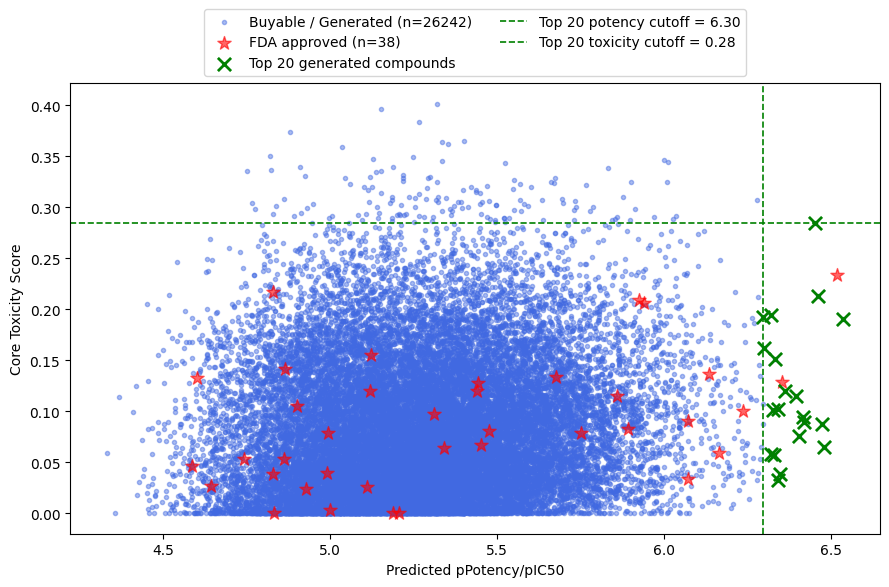

In [60]:
import matplotlib.pyplot as plt

# Dataframes
generatedDF = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_core.copy()
fdaDF = drugBankDrug_FDAapproved_antiviral_wToxicity_core.copy()

# Keep only rows with required columns
generatedDF = generatedDF[
    generatedDF["pPotency_prediction"].notna() &
    generatedDF["Core_Toxicity_Score"].notna()
].copy()

fdaDF = fdaDF[
    fdaDF["pPotency_prediction"].notna() &
    fdaDF["Core_Toxicity_Score"].notna()
].copy()

# Top 20 generated compounds:
# highest potency first, then lowest toxicity
topN = 20
topGeneratedDF = (
    generatedDF
    .sort_values(
        by=["pPotency_prediction", "Core_Toxicity_Score"],
        ascending=[False, True]
    )
    .head(topN)
    .copy()
)

# Threshold lines from top 20 generated compounds
potencyLine = topGeneratedDF["pPotency_prediction"].min()
toxicityLine = topGeneratedDF["Core_Toxicity_Score"].max()

generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
topCount = len(topGeneratedDF)

plt.figure(figsize=(9, 6))

# Buyable / generated compounds
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Buyable / Generated (n={generatedCount})"
)

# FDA-approved antiviral compounds
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_Score"],
    alpha=0.6,
    marker="*",
    c="red",
    s=100,
    label=f"FDA approved (n={fdaCount})"
)

# Top 20 generated compounds
plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="green",
    linewidths=2,
    label=f"Top 20 generated compounds"
)

# Threshold lines from top 20 generated compounds
plt.axvline(
    x=potencyLine,
    c="green",
    linestyle="--",
    linewidth=1.2,
    label=f"Top 20 potency cutoff = {potencyLine:.2f}"
)

plt.axhline(
    y=toxicityLine,
    c="green",
    linestyle="--",
    linewidth=1.2,
    label=f"Top 20 toxicity cutoff = {toxicityLine:.2f}"
)

plt.xlabel("Predicted pPotency/pIC50")
plt.ylabel("Core Toxicity Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=2)
plt.tight_layout()
svg_path = os.path.join(saveDir, "combinedEbolaVirus_wART_Buyable_plot_pPotency_CoreToxicity.svg")
png_path = os.path.join(saveDir, "combinedEbolaVirus_wART_Buyable_plot_pPotency_CoreToxicity.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Add `Mechanistic_Alert_Score` & `ADME_Liability_Score` with `Toxicity`

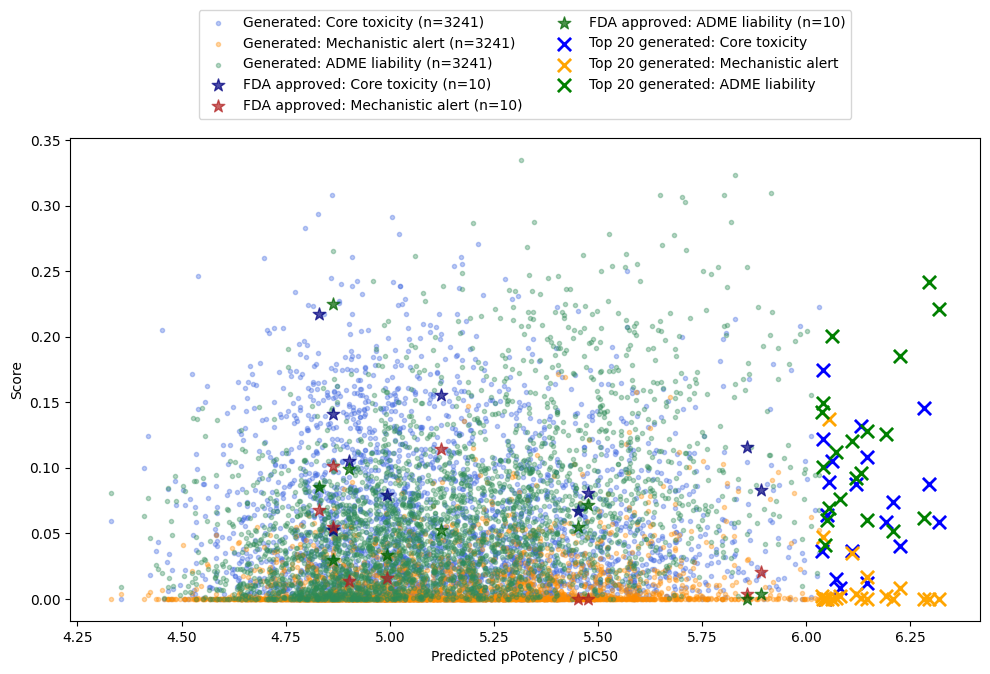

In [21]:
import os
import matplotlib.pyplot as plt

# Best generated compounds after full ADMET filtering
generatedDF = combinedEbolaVirus_wART_Buyable_predicted_all_wToxicity_ADMET.copy()
fdaDF = drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET.copy()

requiredCols = [
    "pPotency_prediction",
    "Core_Toxicity_Score",
    "Mechanistic_Alert_Score",
    "ADME_Liability_Score"
]

generatedDF = generatedDF.dropna(subset=requiredCols).copy()
fdaDF = fdaDF.dropna(subset=requiredCols).copy()

# Rank generated compounds by potency first, then lowest liabilities
bestGeneratedDF = (
    generatedDF
    .sort_values(
        by=[
            "pPotency_prediction",
            "Core_Toxicity_Score",
            "Mechanistic_Alert_Score",
            "ADME_Liability_Score"
        ],
        ascending=[False, True, True, True]
    )
    .reset_index(drop=True)
)

topN = 20
topGeneratedDF = bestGeneratedDF.head(topN).copy()

generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
topCount = len(topGeneratedDF)

plt.figure(figsize=(10, 7))

# Generated compounds
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_Score"],
    alpha=0.35,
    marker=".",
    c="royalblue",
    label=f"Generated: Core toxicity (n={generatedCount})"
)

plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Mechanistic_Alert_Score"],
    alpha=0.35,
    marker=".",
    c="darkorange",
    label=f"Generated: Mechanistic alert (n={generatedCount})"
)

plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["ADME_Liability_Score"],
    alpha=0.35,
    marker=".",
    c="seagreen",
    label=f"Generated: ADME liability (n={generatedCount})"
)

# FDA-approved reference compounds
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="navy",
    label=f"FDA approved: Core toxicity (n={fdaCount})"
)

plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Mechanistic_Alert_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="firebrick",
    label=f"FDA approved: Mechanistic alert (n={fdaCount})"
)

plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["ADME_Liability_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="darkgreen",
    label=f"FDA approved: ADME liability (n={fdaCount})"
)

# Top generated compounds
plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="blue",
    linewidths=2,
    label=f"Top {topN} generated: Core toxicity"
)

plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Mechanistic_Alert_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="orange",
    linewidths=2,
    label=f"Top {topN} generated: Mechanistic alert"
)

plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["ADME_Liability_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="green",
    linewidths=2,
    label=f"Top {topN} generated: ADME liability"
)

plt.xlabel("Predicted pPotency / pIC50")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.28), ncol=2)
plt.tight_layout()

svg_path = os.path.join(saveDir, "combinedEbolaVirus_wART_Buyable_plot_bestCompounds_AllThreeScores.svg")
png_path = os.path.join(saveDir, "combinedEbolaVirus_wART_Buyable_plot_bestCompounds_AllThreeScores.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

## Check toxicty for `Inosibe + Adenosine + Guanosine + Xanthosine` DORANET generated AntiviralsData set

In [22]:
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')
max_val = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all

pPotency_prediction range: 4.619 → 5.785


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,5.110976,0.607729,3.919828,6.302124,0.000008,4.987419e-07,0.000120
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3,5.182013,0.608463,3.989425,6.374601,0.000007,4.220843e-07,0.000102
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028
...,...,...,...,...,...,...,...,...,...,...
20367,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3,5.095807,0.608255,3.903627,6.287987,0.000008,5.152441e-07,0.000125
20368,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.004001,0.613899,3.800758,6.207243,0.000010,6.205213e-07,0.000158
20369,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.046440,0.612875,3.845205,6.247675,0.000009,5.653599e-07,0.000143
20370,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3,5.079011,0.611216,3.881028,6.276994,0.000008,5.284525e-07,0.000132


### Read predicted ADMET properties for all candidate SMILES

In [23]:
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity = pd.read_csv(ARTresultsDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction_wToxicity.csv')
max_val = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity

pPotency_prediction range: 4.619 → 5.785


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.110976,0.607729,3.919828,6.302124,0.000008,4.987419e-07,0.000120,268.229,-2.26890,...,14.967041,41.954246,10.856921,46.413339,0.038775,28.034122,6.475378,9.965103,82.241179,24.156650
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062,507.182,-1.62900,...,5.428461,23.381155,54.633579,87.398216,4.652966,9.112059,36.719659,28.887166,89.414502,9.732454
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034,785.557,-2.42396,...,5.893757,12.563009,56.688639,69.910818,4.071345,53.392788,39.433889,46.219465,82.939124,2.326483
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028,787.573,-1.75026,...,4.769290,15.936409,61.962001,83.365646,3.140752,61.186506,42.807290,44.784800,85.071733,7.134548
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.552294,0.610700,4.355322,6.749266,0.000003,1.781287e-07,0.000044,744.417,-2.89890,...,3.799922,19.542458,50.872431,92.904226,2.869329,13.803800,30.050407,24.505622,92.594029,16.401706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7312,N#CC(O)(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[n...,4.973250,0.611276,3.775148,6.171351,0.000011,6.739823e-07,0.000168,350.247,-3.86964,...,13.028306,10.275301,5.273362,60.333463,0.775494,83.326871,12.252811,28.266770,70.065917,57.619232
7313,N#CC(O)(O)[C@H]1O[C@](C#N)(n2cnc3c(=O)[nH]c(=O...,5.029831,0.609572,3.835070,6.224592,0.000009,5.962222e-07,0.000146,350.247,-4.08564,...,15.238465,8.491663,3.450950,70.182241,1.008143,86.583947,12.214036,29.623885,66.731291,26.987204
7314,N#Cc1nc2c(=O)[nH]c(=O)[nH]c2n1[C@@H]1O[C@H](C(...,4.993202,0.610283,3.797047,6.189357,0.000010,6.466113e-07,0.000160,350.247,-3.89174,...,14.734393,12.252811,7.754944,65.335401,1.046917,80.961613,12.756883,29.274913,66.227220,36.060489
7315,O=C1NC2=NC(=O)[C@H]3O[C@H]([C@H](O)[C@@H]3O)n3...,5.228329,0.608842,4.035000,6.421659,0.000006,3.787402e-07,0.000092,279.212,-2.07580,...,18.611865,9.771229,11.709965,92.904226,0.038775,34.431950,8.801861,11.516092,65.568050,10.197751


### Retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [24]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.columns
]

combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.shape)
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.head()

Filtered dataframe shape: (7317, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.110976,0.607729,3.919828,6.302124,0.000008,4.987419e-07,0.000120,0.591952,0.052745,...,0.016266,0.583451,0.001874,0.001193,0.083214,0.002164,0.012237,0.000492,0.048260,0.000058
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062,0.033052,0.330824,...,0.024185,0.159878,0.001577,0.034541,0.056855,0.011661,0.015668,0.198030,0.076890,0.001108
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034,0.239975,0.900458,...,0.070120,0.380114,0.007940,0.026014,0.047826,0.052646,0.026518,0.152412,0.267949,0.046004
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028,0.188998,0.908109,...,0.050004,0.349236,0.005862,0.050689,0.057204,0.072706,0.040867,0.214760,0.236050,0.066886
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.552294,0.610700,4.355322,6.749266,0.000003,1.781287e-07,0.000044,0.160844,0.619006,...,0.033647,0.122790,0.001046,0.012560,0.021261,0.009916,0.009539,0.241743,0.165820,0.002698


### Multiparameter optimization (MPO) framework based ADMET scoring

We replaced simple arithmetic averaging with a weighted desirability-based multiparameter optimization (MPO) framework. Each ADMET endpoint was converted to a 0–1 desirability value, where `1 --> favorable` and `0 --> unfavorable` profile. Category-level scores were then combined using weighted geometric means, following the same general pattern used in QED and ADMET-score approaches.

**References**

1. ADMET-score – a comprehensive scoring function for evaluation of chemical drug-likeness (https://pubs.rsc.org/en/content/articlelanding/2019/md/c8md00472b)
2. Quantifying the chemical beauty of drugs (https://www.nature.com/articles/nchem.1243)

In [26]:
# =========================================================
# 1. Endpoint groups
# =========================================================
coreToxicityCols = [
    "AMES", "hERG", "DILI", "ClinTox",
    "Carcinogens_Lagunin", "Skin_Reaction", "LD50_Zhu"
]

mechanisticAlertCols = [
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53",
    "NR-AR-LBD", "NR-AR", "NR-AhR", "NR-Aromatase",
    "NR-ER-LBD", "NR-ER", "NR-PPAR-gamma"
]

admeLowerIsBetter = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith", "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels", "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels", "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels", "CYP3A4_Veith",
]

admeHigherIsBetter = [
    "Caco2_Wang", "HIA_Hou", "PAMPA_NCATS", "Bioavailability_Ma"
]

# Keep BBB optional for anti-infective projects
includeBBB = False
if includeBBB:
    admeLowerIsBetter = admeLowerIsBetter + ["BBB_Martins"]

allAdmetCols = sorted(set(
    coreToxicityCols + mechanisticAlertCols + admeLowerIsBetter + admeHigherIsBetter
))

# =========================================================
# 2. Input data
# =========================================================
candidateDF = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity.copy()
referenceDF = drugBankDrug_FDAapproved_antiviral_wToxicity.copy()

# Only keep ADMET columns that actually exist in both datasets
availableCols = [
    col for col in allAdmetCols
    if col in candidateDF.columns and col in referenceDF.columns
]

coreAvailable = [col for col in coreToxicityCols if col in availableCols]
mechAvailable = [col for col in mechanisticAlertCols if col in availableCols]
admeLowerAvailable = [col for col in admeLowerIsBetter if col in availableCols]
admeHigherAvailable = [col for col in admeHigherIsBetter if col in availableCols]

# =========================================================
# 3. Reference statistics from FDA-approved antivirals
#    A) Percentiles for Stage 1/2 filtering
#    B) Mean/std for desirability scoring
# =========================================================
referenceNumericDF = referenceDF[availableCols].apply(pd.to_numeric, errors="coerce")

percentileSummaryDF = (
    referenceNumericDF
    .agg([
        lambda x: x.quantile(0.10),
        lambda x: x.quantile(0.90)
    ])
    .T
)
percentileSummaryDF.columns = ["q10", "q90"]

meanStdSummaryDF = (
    referenceNumericDF
    .agg(["mean", lambda x: x.std(ddof=0)])
    .T
)
meanStdSummaryDF.columns = ["Mean", "Std"]

percentileDict = percentileSummaryDF.to_dict(orient="index")
meanStdDict = meanStdSummaryDF.to_dict(orient="index")

# =========================================================
# 4. Helper functions
# =========================================================
epsilon = 1e-6

def clip01(series):
    return series.clip(lower=epsilon, upper=1 - epsilon)

def buildPercentileMask(df, lowerIsBetterCols, higherIsBetterCols, percentileDict):
    mask = pd.Series(True, index=df.index)

    for col in lowerIsBetterCols:
        if col not in df.columns or col not in percentileDict:
            continue
        series = pd.to_numeric(df[col], errors="coerce")
        mask &= series <= percentileDict[col]["q90"]

    for col in higherIsBetterCols:
        if col not in df.columns or col not in percentileDict:
            continue
        series = pd.to_numeric(df[col], errors="coerce")
        mask &= series >= percentileDict[col]["q10"]

    return mask

def desirabilityLowerIsBetter(series, endpointName, meanStdDict):
    meanVal = meanStdDict[endpointName]["Mean"]
    stdVal = meanStdDict[endpointName]["Std"]

    if pd.isna(meanVal) or pd.isna(stdVal) or stdVal <= 0:
        return pd.Series(0.5, index=series.index)

    z = (series - meanVal) / stdVal
    desirability = np.where(series <= meanVal, 1.0, np.exp(-0.5 * z**2))
    return clip01(pd.Series(desirability, index=series.index))

def desirabilityHigherIsBetter(series, endpointName, meanStdDict):
    meanVal = meanStdDict[endpointName]["Mean"]
    stdVal = meanStdDict[endpointName]["Std"]

    if pd.isna(meanVal) or pd.isna(stdVal) or stdVal <= 0:
        return pd.Series(0.5, index=series.index)

    z = (meanVal - series) / stdVal
    desirability = np.where(series >= meanVal, 1.0, np.exp(-0.5 * z**2))
    return clip01(pd.Series(desirability, index=series.index))

def weightedGeometricMean(dfValues, weightsDict):
    cols = [col for col in weightsDict if col in dfValues.columns]
    if len(cols) == 0:
        return pd.Series(np.nan, index=dfValues.index)

    weights = np.array([weightsDict[col] for col in cols], dtype=float)
    weights = weights / weights.sum()

    values = dfValues[cols].copy().clip(lower=epsilon, upper=1 - epsilon)
    return np.exp(np.log(values).mul(weights, axis=1).sum(axis=1))

def addDesirabilityScores(df):
    df = df.copy()

    coreWeights = {col: 1.0 for col in coreAvailable}
    mechWeights = {col: 1.0 for col in mechAvailable}
    admeWeights = {col: 1.0 for col in (admeLowerAvailable + admeHigherAvailable)}

    coreDesDF = pd.DataFrame(index=df.index)
    for col in coreAvailable:
        coreDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    mechDesDF = pd.DataFrame(index=df.index)
    for col in mechAvailable:
        mechDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    admeDesDF = pd.DataFrame(index=df.index)
    for col in admeLowerAvailable:
        admeDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )
    for col in admeHigherAvailable:
        admeDesDF[col] = desirabilityHigherIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    df["Core_Toxicity_Desirability"] = weightedGeometricMean(coreDesDF, coreWeights)
    df["Core_Toxicity_Score"] = 1 - df["Core_Toxicity_Desirability"]

    df["Mechanistic_Alert_Desirability"] = weightedGeometricMean(mechDesDF, mechWeights)
    df["Mechanistic_Alert_Score"] = 1 - df["Mechanistic_Alert_Desirability"]

    df["ADME_Desirability"] = weightedGeometricMean(admeDesDF, admeWeights)
    df["ADME_Liability_Score"] = 1 - df["ADME_Desirability"]

    return df

def keepConciseColumns(df):
    keepCols = [col for col in ["SMILES", "smiles", "ATC_code", "Drug_Type", "pPotency_prediction", "pPotency_std"] if col in df.columns]
    scoreCols = [
        "Core_Toxicity_Desirability", "Core_Toxicity_Score",
        "Mechanistic_Alert_Desirability", "Mechanistic_Alert_Score",
        "ADME_Desirability", "ADME_Liability_Score"
    ]
    keepCols += [col for col in scoreCols if col in df.columns]
    return df[keepCols].copy()

# =========================================================
# 5. Add score columns to both datasets
# =========================================================
candidateScoredDF = addDesirabilityScores(candidateDF)
referenceScoredDF = addDesirabilityScores(referenceDF)

# =========================================================
# 6. Stage 1: percentile-based toxicity-first filtering
#    lower-is-better endpoints must be <= antiviral q90
# =========================================================
candidateCoreMask = buildPercentileMask(
    candidateScoredDF,
    lowerIsBetterCols=coreAvailable,
    higherIsBetterCols=[],
    percentileDict=percentileDict
)

referenceCoreMask = buildPercentileMask(
    referenceScoredDF,
    lowerIsBetterCols=coreAvailable,
    higherIsBetterCols=[],
    percentileDict=percentileDict
)

candidateCoreDF = candidateScoredDF.loc[candidateCoreMask].reset_index(drop=True)
referenceCoreDF = referenceScoredDF.loc[referenceCoreMask].reset_index(drop=True)

# =========================================================
# 7. Stage 2: percentile-based mechanistic/ADME filtering
#    mechanistic + ADME liabilities <= q90
#    favorable ADME endpoints >= q10
# =========================================================
candidateAdmetMask = buildPercentileMask(
    candidateCoreDF,
    lowerIsBetterCols=mechAvailable + admeLowerAvailable,
    higherIsBetterCols=admeHigherAvailable,
    percentileDict=percentileDict
)

referenceAdmetMask = buildPercentileMask(
    referenceCoreDF,
    lowerIsBetterCols=mechAvailable + admeLowerAvailable,
    higherIsBetterCols=admeHigherAvailable,
    percentileDict=percentileDict
)

candidateAdmetDF = candidateCoreDF.loc[candidateAdmetMask].reset_index(drop=True)
referenceAdmetDF = referenceCoreDF.loc[referenceAdmetMask].reset_index(drop=True)

# =========================================================
# 8. Final concise output dataframes
# =========================================================
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core = keepConciseColumns(candidateCoreDF)
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_ADMET = keepConciseColumns(candidateAdmetDF)

drugBankDrug_FDAapproved_antiviral_wToxicity_core = keepConciseColumns(referenceCoreDF)
drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET = keepConciseColumns(referenceAdmetDF)

print(f"combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core: {combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core.shape}")
print(f"combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_ADMET: {combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_ADMET.shape}")
print(f"drugBankDrug_FDAapproved_antiviral_wToxicity_core: {drugBankDrug_FDAapproved_antiviral_wToxicity_core.shape}")
print(f"drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET: {drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET.shape}")

combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core: (3351, 9)
combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_ADMET: (916, 9)
drugBankDrug_FDAapproved_antiviral_wToxicity_core: (38, 11)
drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET: (10, 11)


### Define filter for compound ranking based on `ADMET` scores

### Plot full distribution + highlighted filtered dataframe

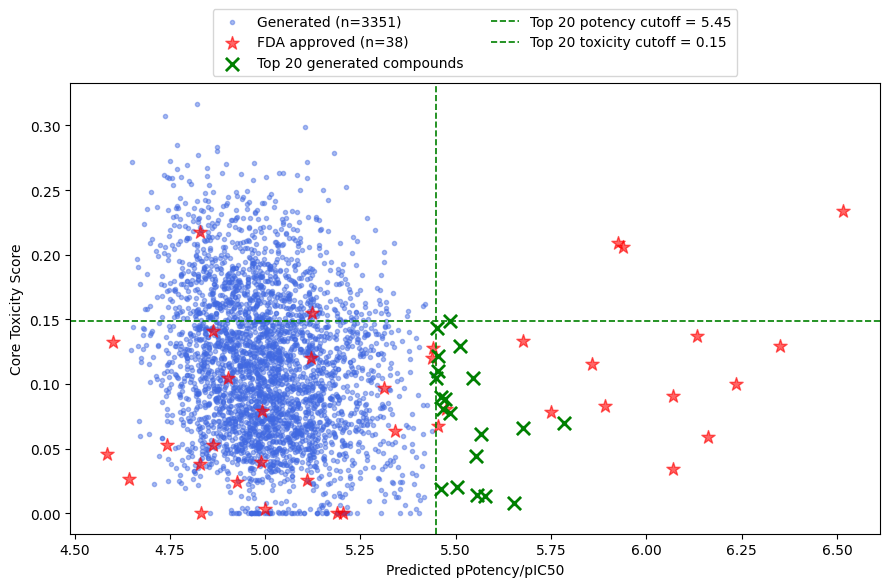

In [35]:
import matplotlib.pyplot as plt

# Dataframes
generatedDF = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core.copy()
fdaDF = drugBankDrug_FDAapproved_antiviral_wToxicity_core.copy()

# Keep only rows with required columns
generatedDF = generatedDF[
    generatedDF["pPotency_prediction"].notna() &
    generatedDF["Core_Toxicity_Score"].notna()
].copy()

fdaDF = fdaDF[
    fdaDF["pPotency_prediction"].notna() &
    fdaDF["Core_Toxicity_Score"].notna()
].copy()

# Top 20 generated compounds:
# highest potency first, then lowest toxicity
topN = 20
topGeneratedDF = (
    generatedDF
    .sort_values(
        by=["pPotency_prediction", "Core_Toxicity_Score"],
        ascending=[False, True]
    )
    .head(topN)
    .copy()
)

# Threshold lines from top 20 generated compounds
potencyLine = topGeneratedDF["pPotency_prediction"].min()
toxicityLine = topGeneratedDF["Core_Toxicity_Score"].max()

generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
topCount = len(topGeneratedDF)

plt.figure(figsize=(9, 6))

# Buyable / generated compounds
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Generated (n={generatedCount})"
)

# FDA-approved antiviral compounds
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_Score"],
    alpha=0.6,
    marker="*",
    c="red",
    s=100,
    label=f"FDA approved (n={fdaCount})"
)

# Top 20 generated compounds
plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="green",
    linewidths=2,
    label=f"Top 20 generated compounds"
)

# Threshold lines from top 20 generated compounds
plt.axvline(
    x=potencyLine,
    c="green",
    linestyle="--",
    linewidth=1.2,
    label=f"Top 20 potency cutoff = {potencyLine:.2f}"
)

plt.axhline(
    y=toxicityLine,
    c="green",
    linestyle="--",
    linewidth=1.2,
    label=f"Top 20 toxicity cutoff = {toxicityLine:.2f}"
)

plt.xlabel("Predicted pPotency/pIC50")
plt.ylabel("Core Toxicity Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=2)
plt.tight_layout()
svg_path = os.path.join(saveDir, "combinedEbolaVirus_wART_allDORAnetGenerated_CoreToxicity.svg")
png_path = os.path.join(saveDir, "combinedEbolaVirus_wART_allDORAnetGenerated_CoreToxicity.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Add `Mechanistic_Alert_Score` & `ADME_Liability_Score` with `Toxicity`

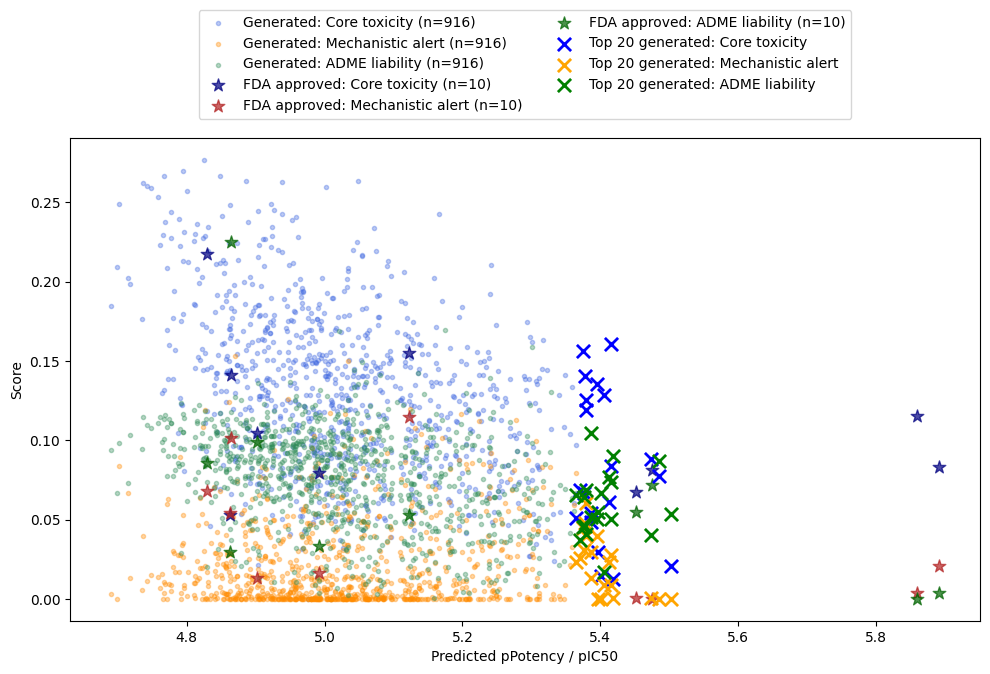

In [36]:
import os
import matplotlib.pyplot as plt

# Best generated compounds after full ADMET filtering
generatedDF = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_ADMET.copy()
fdaDF = drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET.copy()

requiredCols = [
    "pPotency_prediction",
    "Core_Toxicity_Score",
    "Mechanistic_Alert_Score",
    "ADME_Liability_Score"
]

generatedDF = generatedDF.dropna(subset=requiredCols).copy()
fdaDF = fdaDF.dropna(subset=requiredCols).copy()

# Rank generated compounds by potency first, then lowest liabilities
bestGeneratedDF = (
    generatedDF
    .sort_values(
        by=[
            "pPotency_prediction",
            "Core_Toxicity_Score",
            "Mechanistic_Alert_Score",
            "ADME_Liability_Score"
        ],
        ascending=[False, True, True, True]
    )
    .reset_index(drop=True)
)

topN = 20
topGeneratedDF = bestGeneratedDF.head(topN).copy()

generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
topCount = len(topGeneratedDF)

plt.figure(figsize=(10, 7))

# Generated compounds
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_Score"],
    alpha=0.35,
    marker=".",
    c="royalblue",
    label=f"Generated: Core toxicity (n={generatedCount})"
)

plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Mechanistic_Alert_Score"],
    alpha=0.35,
    marker=".",
    c="darkorange",
    label=f"Generated: Mechanistic alert (n={generatedCount})"
)

plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["ADME_Liability_Score"],
    alpha=0.35,
    marker=".",
    c="seagreen",
    label=f"Generated: ADME liability (n={generatedCount})"
)

# FDA-approved reference compounds
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="navy",
    label=f"FDA approved: Core toxicity (n={fdaCount})"
)

plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Mechanistic_Alert_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="firebrick",
    label=f"FDA approved: Mechanistic alert (n={fdaCount})"
)

plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["ADME_Liability_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="darkgreen",
    label=f"FDA approved: ADME liability (n={fdaCount})"
)

# Top generated compounds
plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="blue",
    linewidths=2,
    label=f"Top {topN} generated: Core toxicity"
)

plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Mechanistic_Alert_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="orange",
    linewidths=2,
    label=f"Top {topN} generated: Mechanistic alert"
)

plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["ADME_Liability_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="green",
    linewidths=2,
    label=f"Top {topN} generated: ADME liability"
)

plt.xlabel("Predicted pPotency / pIC50")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.28), ncol=2)
plt.tight_layout()

svg_path = os.path.join(saveDir, "combinedEbolaVirus_wART_allDORAnetGenerated_AllThreeScores.svg")
png_path = os.path.join(saveDir, "combinedEbolaVirus_wART_allDORAnetGenerated_AllThreeScores.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

In [37]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
df = combinedEbolaVirus_wART_allDORAnetGenerated_predicted_all_wToxicity_core

# Predicted pPotency from the new dataframe
predicted_pPotency = df['pPotency_prediction'].values

top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]  # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM   = 10**(-highest_pPotency) * 1e6
top_20_std = df['pPotency_std'].values[top_20_idx]


print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.3f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.3f} µM)")
print(f"Mean pPotency_std over top-20: {np.mean(top_20_std):.3f}")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.3f} - {best_IC50_uM:.3f} µM")

Top 20 compounds cutoff pPotency: 5.45 (IC50: 3.568 µM)
Highest predicted pPotency: 5.79 (IC50: 1.639 µM)
Mean pPotency_std over top-20: 0.611
pPotency range of top 20 compounds: pPotency --> 5.45 - 5.79; IC50 --> 3.568 - 1.639 µM


## Check toxicty for `Inosine-substructures` DORANET generated AntiviralsData set

In [38]:
combinedEbolaVirus_wART_InosineSubstructures_predicted_all = pd.read_csv(ARTresultsDir + 'combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction.csv')
max_val = combinedEbolaVirus_wART_InosineSubstructures_predicted_all['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_InosineSubstructures_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_InosineSubstructures_predicted_all

pPotency_prediction range: 4.702 → 6.048


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,5.182013,0.608463,3.989425,6.374601,0.000007,4.220843e-07,0.000102
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.330797,0.610017,4.135163,6.526430,0.000005,2.975568e-07,0.000073
...,...,...,...,...,...,...,...,...
20875,O=C1Oc2nc3c(c(=O)[nH]2)n1c[n+]3[C@@H]1O[C@H](C...,5.141413,0.607802,3.950120,6.332705,0.000007,4.648310e-07,0.000112
20876,O=C(O)n1c[n+]([C@@H]2O[C@H](C(O)O)[C@@H](O)[C@...,5.249452,0.607519,4.058715,6.440190,0.000006,3.629195e-07,0.000087
20877,N#CC(O)(O)[C@H]1O[C@@H]([n+]2cn(C(=O)O)c3c(=O)...,5.173319,0.609265,3.979158,6.367479,0.000007,4.290632e-07,0.000105
20878,NC(=O)[C@H]1O[C@@H]([n+]2cn(C(=O)O)c3c(=O)[nH]...,5.145128,0.610115,3.949303,6.340952,0.000007,4.560870e-07,0.000112


### Read predicted ADMET properties for all candidate SMILES

In [39]:
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity = pd.read_csv(ARTresultsDir + 'combinedEbolaVirusData_InosineSubstructures_DORAnetGenerated_ARTprediction_wToxicity.csv')
max_val = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity

pPotency_prediction range: 4.702 → 6.048


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062,507.182,-1.62900,...,5.428461,23.381155,54.633579,87.398216,4.652966,9.112059,36.719659,28.887166,89.414502,9.732454
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034,785.557,-2.42396,...,5.893757,12.563009,56.688639,69.910818,4.071345,53.392788,39.433889,46.219465,82.939124,2.326483
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028,787.573,-1.75026,...,4.769290,15.936409,61.962001,83.365646,3.140752,61.186506,42.807290,44.784800,85.071733,7.134548
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.552294,0.610700,4.355322,6.749266,0.000003,1.781287e-07,0.000044,744.417,-2.89890,...,3.799922,19.542458,50.872431,92.904226,2.869329,13.803800,30.050407,24.505622,92.594029,16.401706
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.677128,0.612279,4.477060,6.877195,0.000002,1.326798e-07,0.000033,745.425,-2.56940,...,4.226444,29.701435,76.075998,88.096161,3.722373,29.352462,35.944164,27.142303,91.081815,2.791780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3230,O=C1Oc2n1c1c(=O)[nH]cnc1[n+]2[C@@H]1O[C@H](C(O...,5.147525,0.608119,3.955612,6.339437,0.000007,4.576807e-07,0.000111,327.229,-3.69750,...,19.503684,22.915859,3.373401,53.354013,1.008143,47.925553,6.863125,21.946491,74.486235,53.005041
3231,O=C(O)n1c[n+]2c3nc([nH]c(=O)c31)O[C@@H]1[C@H](...,5.100356,0.609073,3.906574,6.294139,0.000008,5.079968e-07,0.000124,327.229,-3.13180,...,12.834432,14.850717,3.101978,47.809228,1.046917,34.625824,2.055060,21.675068,72.974021,47.460256
3232,O=C1Oc2nc3c(c(=O)[nH]2)n1c[n+]3[C@@H]1O[C@H](C...,5.141413,0.607802,3.950120,6.332705,0.000007,4.648310e-07,0.000112,327.229,-3.69750,...,18.611865,25.901512,5.506010,60.953858,0.387747,59.131446,7.948817,22.915859,72.043428,49.205118
3233,O=C(O)n1c[n+]([C@@H]2O[C@H](C(O)O)[C@@H](O)[C@...,5.249452,0.607519,4.058715,6.440190,0.000006,3.629195e-07,0.000087,329.245,-3.53190,...,9.538581,32.221791,7.056999,53.198914,0.155099,22.295463,2.055060,13.726250,78.208608,67.661884


### Retain potency predictions along with toxicity, mechanistic, and ADME-related endpoints

In [40]:
# Potency-related columns
potencyCols = [
    "SMILES",
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity.columns
]

combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity[selectedCols].copy()

print("Filtered dataframe shape:", combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity.shape)
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity.head()

Filtered dataframe shape: (3235, 41)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,AMES,hERG,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.412802,0.613704,4.209943,6.615661,0.000004,2.422918e-07,0.000062,0.033052,0.330824,...,0.024185,0.159878,0.001577,0.034541,0.056855,0.011661,0.015668,0.198030,0.076890,0.001108
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.668057,0.614157,4.464309,6.871804,0.000002,1.343370e-07,0.000034,0.239975,0.900458,...,0.070120,0.380114,0.007940,0.026014,0.047826,0.052646,0.026518,0.152412,0.267949,0.046004
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.757816,0.613533,4.555292,6.960340,0.000002,1.095619e-07,0.000028,0.188998,0.908109,...,0.050004,0.349236,0.005862,0.050689,0.057204,0.072706,0.040867,0.214760,0.236050,0.066886
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.552294,0.610700,4.355322,6.749266,0.000003,1.781287e-07,0.000044,0.160844,0.619006,...,0.033647,0.122790,0.001046,0.012560,0.021261,0.009916,0.009539,0.241743,0.165820,0.002698
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.677128,0.612279,4.477060,6.877195,0.000002,1.326798e-07,0.000033,0.198825,0.550806,...,0.056442,0.123578,0.001490,0.031071,0.019455,0.017940,0.009144,0.228861,0.219715,0.009885


### Multiparameter optimization (MPO) framework based ADMET scoring

We replaced simple arithmetic averaging with a weighted desirability-based multiparameter optimization (MPO) framework. Each ADMET endpoint was converted to a 0–1 desirability value, where `1 --> favorable` and `0 --> unfavorable` profile. Category-level scores were then combined using weighted geometric means, following the same general pattern used in QED and ADMET-score approaches.

**References**

1. ADMET-score – a comprehensive scoring function for evaluation of chemical drug-likeness (https://pubs.rsc.org/en/content/articlelanding/2019/md/c8md00472b)
2. Quantifying the chemical beauty of drugs (https://www.nature.com/articles/nchem.1243)

In [41]:
# =========================================================
# 1. Endpoint groups
# =========================================================
coreToxicityCols = [
    "AMES", "hERG", "DILI", "ClinTox",
    "Carcinogens_Lagunin", "Skin_Reaction", "LD50_Zhu"
]

mechanisticAlertCols = [
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53",
    "NR-AR-LBD", "NR-AR", "NR-AhR", "NR-Aromatase",
    "NR-ER-LBD", "NR-ER", "NR-PPAR-gamma"
]

admeLowerIsBetter = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith", "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels", "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels", "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels", "CYP3A4_Veith",
]

admeHigherIsBetter = [
    "Caco2_Wang", "HIA_Hou", "PAMPA_NCATS", "Bioavailability_Ma"
]

# Keep BBB optional for anti-infective projects
includeBBB = False
if includeBBB:
    admeLowerIsBetter = admeLowerIsBetter + ["BBB_Martins"]

allAdmetCols = sorted(set(
    coreToxicityCols + mechanisticAlertCols + admeLowerIsBetter + admeHigherIsBetter
))

# =========================================================
# 2. Input data
# =========================================================
candidateDF = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity.copy()
referenceDF = drugBankDrug_FDAapproved_antiviral_wToxicity.copy()

# Only keep ADMET columns that actually exist in both datasets
availableCols = [
    col for col in allAdmetCols
    if col in candidateDF.columns and col in referenceDF.columns
]

coreAvailable = [col for col in coreToxicityCols if col in availableCols]
mechAvailable = [col for col in mechanisticAlertCols if col in availableCols]
admeLowerAvailable = [col for col in admeLowerIsBetter if col in availableCols]
admeHigherAvailable = [col for col in admeHigherIsBetter if col in availableCols]

# =========================================================
# 3. Reference statistics from FDA-approved antivirals
#    A) Percentiles for Stage 1/2 filtering
#    B) Mean/std for desirability scoring
# =========================================================
referenceNumericDF = referenceDF[availableCols].apply(pd.to_numeric, errors="coerce")

percentileSummaryDF = (
    referenceNumericDF
    .agg([
        lambda x: x.quantile(0.10),
        lambda x: x.quantile(0.90)
    ])
    .T
)
percentileSummaryDF.columns = ["q10", "q90"]

meanStdSummaryDF = (
    referenceNumericDF
    .agg(["mean", lambda x: x.std(ddof=0)])
    .T
)
meanStdSummaryDF.columns = ["Mean", "Std"]

percentileDict = percentileSummaryDF.to_dict(orient="index")
meanStdDict = meanStdSummaryDF.to_dict(orient="index")

# =========================================================
# 4. Helper functions
# =========================================================
epsilon = 1e-6

def clip01(series):
    return series.clip(lower=epsilon, upper=1 - epsilon)

def buildPercentileMask(df, lowerIsBetterCols, higherIsBetterCols, percentileDict):
    mask = pd.Series(True, index=df.index)

    for col in lowerIsBetterCols:
        if col not in df.columns or col not in percentileDict:
            continue
        series = pd.to_numeric(df[col], errors="coerce")
        mask &= series <= percentileDict[col]["q90"]

    for col in higherIsBetterCols:
        if col not in df.columns or col not in percentileDict:
            continue
        series = pd.to_numeric(df[col], errors="coerce")
        mask &= series >= percentileDict[col]["q10"]

    return mask

def desirabilityLowerIsBetter(series, endpointName, meanStdDict):
    meanVal = meanStdDict[endpointName]["Mean"]
    stdVal = meanStdDict[endpointName]["Std"]

    if pd.isna(meanVal) or pd.isna(stdVal) or stdVal <= 0:
        return pd.Series(0.5, index=series.index)

    z = (series - meanVal) / stdVal
    desirability = np.where(series <= meanVal, 1.0, np.exp(-0.5 * z**2))
    return clip01(pd.Series(desirability, index=series.index))

def desirabilityHigherIsBetter(series, endpointName, meanStdDict):
    meanVal = meanStdDict[endpointName]["Mean"]
    stdVal = meanStdDict[endpointName]["Std"]

    if pd.isna(meanVal) or pd.isna(stdVal) or stdVal <= 0:
        return pd.Series(0.5, index=series.index)

    z = (meanVal - series) / stdVal
    desirability = np.where(series >= meanVal, 1.0, np.exp(-0.5 * z**2))
    return clip01(pd.Series(desirability, index=series.index))

def weightedGeometricMean(dfValues, weightsDict):
    cols = [col for col in weightsDict if col in dfValues.columns]
    if len(cols) == 0:
        return pd.Series(np.nan, index=dfValues.index)

    weights = np.array([weightsDict[col] for col in cols], dtype=float)
    weights = weights / weights.sum()

    values = dfValues[cols].copy().clip(lower=epsilon, upper=1 - epsilon)
    return np.exp(np.log(values).mul(weights, axis=1).sum(axis=1))

def addDesirabilityScores(df):
    df = df.copy()

    coreWeights = {col: 1.0 for col in coreAvailable}
    mechWeights = {col: 1.0 for col in mechAvailable}
    admeWeights = {col: 1.0 for col in (admeLowerAvailable + admeHigherAvailable)}

    coreDesDF = pd.DataFrame(index=df.index)
    for col in coreAvailable:
        coreDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    mechDesDF = pd.DataFrame(index=df.index)
    for col in mechAvailable:
        mechDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    admeDesDF = pd.DataFrame(index=df.index)
    for col in admeLowerAvailable:
        admeDesDF[col] = desirabilityLowerIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )
    for col in admeHigherAvailable:
        admeDesDF[col] = desirabilityHigherIsBetter(
            pd.to_numeric(df[col], errors="coerce"), col, meanStdDict
        )

    df["Core_Toxicity_Desirability"] = weightedGeometricMean(coreDesDF, coreWeights)
    df["Core_Toxicity_Score"] = 1 - df["Core_Toxicity_Desirability"]

    df["Mechanistic_Alert_Desirability"] = weightedGeometricMean(mechDesDF, mechWeights)
    df["Mechanistic_Alert_Score"] = 1 - df["Mechanistic_Alert_Desirability"]

    df["ADME_Desirability"] = weightedGeometricMean(admeDesDF, admeWeights)
    df["ADME_Liability_Score"] = 1 - df["ADME_Desirability"]

    return df

def keepConciseColumns(df):
    keepCols = [col for col in ["SMILES", "smiles", "ATC_code", "Drug_Type", "pPotency_prediction", "pPotency_std"] if col in df.columns]
    scoreCols = [
        "Core_Toxicity_Desirability", "Core_Toxicity_Score",
        "Mechanistic_Alert_Desirability", "Mechanistic_Alert_Score",
        "ADME_Desirability", "ADME_Liability_Score"
    ]
    keepCols += [col for col in scoreCols if col in df.columns]
    return df[keepCols].copy()

# =========================================================
# 5. Add score columns to both datasets
# =========================================================
candidateScoredDF = addDesirabilityScores(candidateDF)
referenceScoredDF = addDesirabilityScores(referenceDF)

# =========================================================
# 6. Stage 1: percentile-based toxicity-first filtering
#    lower-is-better endpoints must be <= antiviral q90
# =========================================================
candidateCoreMask = buildPercentileMask(
    candidateScoredDF,
    lowerIsBetterCols=coreAvailable,
    higherIsBetterCols=[],
    percentileDict=percentileDict
)

referenceCoreMask = buildPercentileMask(
    referenceScoredDF,
    lowerIsBetterCols=coreAvailable,
    higherIsBetterCols=[],
    percentileDict=percentileDict
)

candidateCoreDF = candidateScoredDF.loc[candidateCoreMask].reset_index(drop=True)
referenceCoreDF = referenceScoredDF.loc[referenceCoreMask].reset_index(drop=True)

# =========================================================
# 7. Stage 2: percentile-based mechanistic/ADME filtering
#    mechanistic + ADME liabilities <= q90
#    favorable ADME endpoints >= q10
# =========================================================
candidateAdmetMask = buildPercentileMask(
    candidateCoreDF,
    lowerIsBetterCols=mechAvailable + admeLowerAvailable,
    higherIsBetterCols=admeHigherAvailable,
    percentileDict=percentileDict
)

referenceAdmetMask = buildPercentileMask(
    referenceCoreDF,
    lowerIsBetterCols=mechAvailable + admeLowerAvailable,
    higherIsBetterCols=admeHigherAvailable,
    percentileDict=percentileDict
)

candidateAdmetDF = candidateCoreDF.loc[candidateAdmetMask].reset_index(drop=True)
referenceAdmetDF = referenceCoreDF.loc[referenceAdmetMask].reset_index(drop=True)

# =========================================================
# 8. Final concise output dataframes
# =========================================================
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_core = keepConciseColumns(candidateCoreDF)
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_ADMET = keepConciseColumns(candidateAdmetDF)

drugBankDrug_FDAapproved_antiviral_wToxicity_core = keepConciseColumns(referenceCoreDF)
drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET = keepConciseColumns(referenceAdmetDF)

print(f"combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_core: {combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_core.shape}")
print(f"combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_ADMET: {combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_ADMET.shape}")
print(f"drugBankDrug_FDAapproved_antiviral_wToxicity_core: {drugBankDrug_FDAapproved_antiviral_wToxicity_core.shape}")
print(f"drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET: {drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET.shape}")

combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_core: (2584, 9)
combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_ADMET: (362, 9)
drugBankDrug_FDAapproved_antiviral_wToxicity_core: (38, 11)
drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET: (10, 11)


### Define filter for compound ranking based on `ADMET` scores

### Plot full distribution + highlighted filtered dataframe

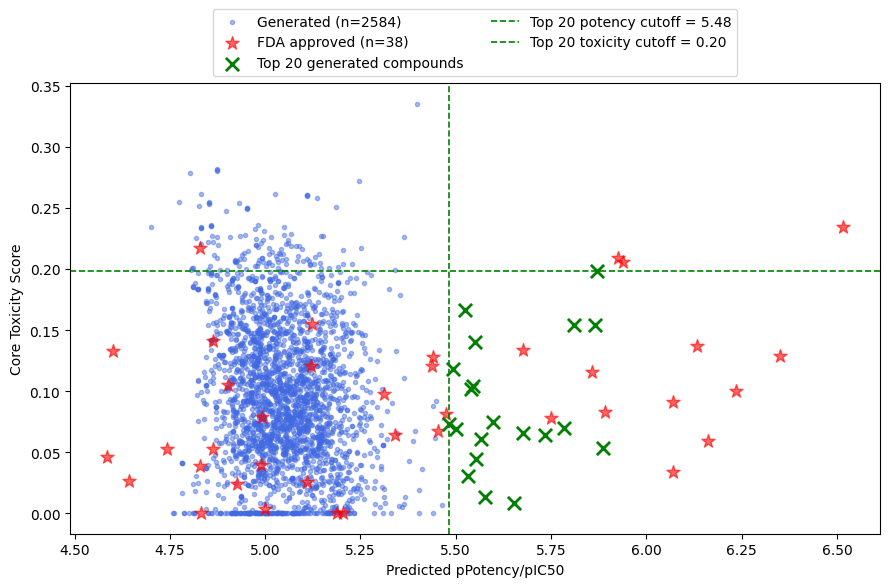

In [42]:
import matplotlib.pyplot as plt

# Dataframes
generatedDF = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_core.copy()
fdaDF = drugBankDrug_FDAapproved_antiviral_wToxicity_core.copy()

# Keep only rows with required columns
generatedDF = generatedDF[
    generatedDF["pPotency_prediction"].notna() &
    generatedDF["Core_Toxicity_Score"].notna()
].copy()

fdaDF = fdaDF[
    fdaDF["pPotency_prediction"].notna() &
    fdaDF["Core_Toxicity_Score"].notna()
].copy()

# Top 20 generated compounds:
# highest potency first, then lowest toxicity
topN = 20
topGeneratedDF = (
    generatedDF
    .sort_values(
        by=["pPotency_prediction", "Core_Toxicity_Score"],
        ascending=[False, True]
    )
    .head(topN)
    .copy()
)

# Threshold lines from top 20 generated compounds
potencyLine = topGeneratedDF["pPotency_prediction"].min()
toxicityLine = topGeneratedDF["Core_Toxicity_Score"].max()

generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
topCount = len(topGeneratedDF)

plt.figure(figsize=(9, 6))

# Buyable / generated compounds
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_Score"],
    alpha=0.45,
    marker=".",
    c="royalblue",
    label=f"Generated (n={generatedCount})"
)

# FDA-approved antiviral compounds
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_Score"],
    alpha=0.6,
    marker="*",
    c="red",
    s=100,
    label=f"FDA approved (n={fdaCount})"
)

# Top 20 generated compounds
plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="green",
    linewidths=2,
    label=f"Top 20 generated compounds"
)

# Threshold lines from top 20 generated compounds
plt.axvline(
    x=potencyLine,
    c="green",
    linestyle="--",
    linewidth=1.2,
    label=f"Top 20 potency cutoff = {potencyLine:.2f}"
)

plt.axhline(
    y=toxicityLine,
    c="green",
    linestyle="--",
    linewidth=1.2,
    label=f"Top 20 toxicity cutoff = {toxicityLine:.2f}"
)

plt.xlabel("Predicted pPotency/pIC50")
plt.ylabel("Core Toxicity Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.18), ncol=2)
plt.tight_layout()
svg_path = os.path.join(saveDir, "combinedEbolaVirus_wART_InosineSubstructures_CoreToxicity.svg")
png_path = os.path.join(saveDir, "combinedEbolaVirus_wART_InosineSubstructures_CoreToxicity.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Add `Mechanistic_Alert_Score` & `ADME_Liability_Score` with `Toxicity`

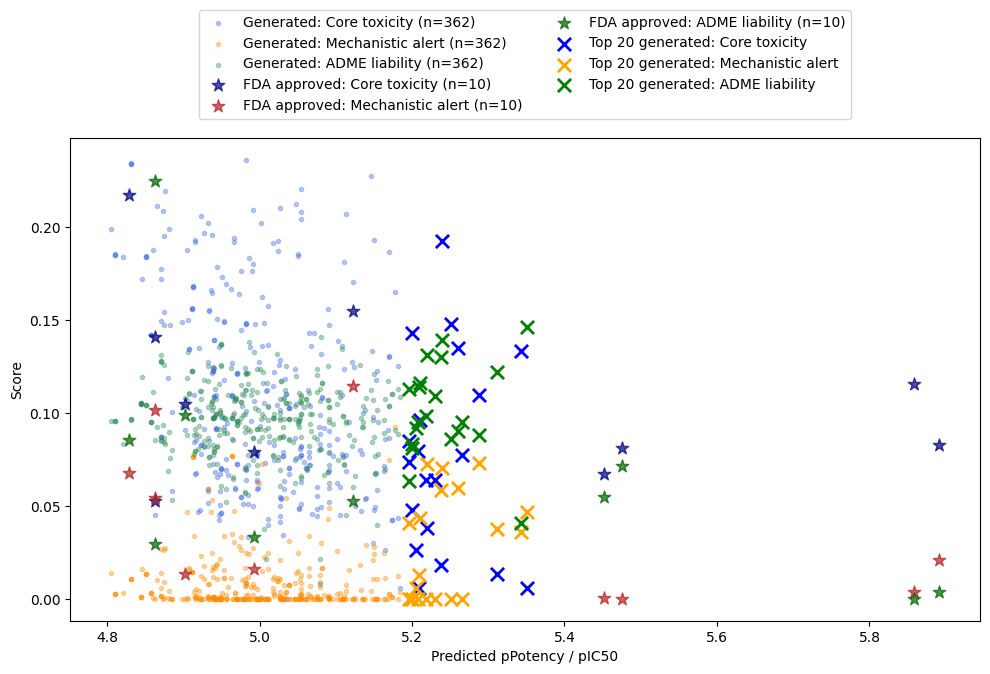

In [43]:
import os
import matplotlib.pyplot as plt

# Best generated compounds after full ADMET filtering
generatedDF = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_ADMET.copy()
fdaDF = drugBankDrug_FDAapproved_antiviral_wToxicity_ADMET.copy()

requiredCols = [
    "pPotency_prediction",
    "Core_Toxicity_Score",
    "Mechanistic_Alert_Score",
    "ADME_Liability_Score"
]

generatedDF = generatedDF.dropna(subset=requiredCols).copy()
fdaDF = fdaDF.dropna(subset=requiredCols).copy()

# Rank generated compounds by potency first, then lowest liabilities
bestGeneratedDF = (
    generatedDF
    .sort_values(
        by=[
            "pPotency_prediction",
            "Core_Toxicity_Score",
            "Mechanistic_Alert_Score",
            "ADME_Liability_Score"
        ],
        ascending=[False, True, True, True]
    )
    .reset_index(drop=True)
)

topN = 20
topGeneratedDF = bestGeneratedDF.head(topN).copy()

generatedCount = len(generatedDF)
fdaCount = len(fdaDF)
topCount = len(topGeneratedDF)

plt.figure(figsize=(10, 7))

# Generated compounds
plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Core_Toxicity_Score"],
    alpha=0.35,
    marker=".",
    c="royalblue",
    label=f"Generated: Core toxicity (n={generatedCount})"
)

plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["Mechanistic_Alert_Score"],
    alpha=0.35,
    marker=".",
    c="darkorange",
    label=f"Generated: Mechanistic alert (n={generatedCount})"
)

plt.scatter(
    generatedDF["pPotency_prediction"],
    generatedDF["ADME_Liability_Score"],
    alpha=0.35,
    marker=".",
    c="seagreen",
    label=f"Generated: ADME liability (n={generatedCount})"
)

# FDA-approved reference compounds
plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Core_Toxicity_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="navy",
    label=f"FDA approved: Core toxicity (n={fdaCount})"
)

plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["Mechanistic_Alert_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="firebrick",
    label=f"FDA approved: Mechanistic alert (n={fdaCount})"
)

plt.scatter(
    fdaDF["pPotency_prediction"],
    fdaDF["ADME_Liability_Score"],
    alpha=0.7,
    marker="*",
    s=90,
    c="darkgreen",
    label=f"FDA approved: ADME liability (n={fdaCount})"
)

# Top generated compounds
plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Core_Toxicity_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="blue",
    linewidths=2,
    label=f"Top {topN} generated: Core toxicity"
)

plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["Mechanistic_Alert_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="orange",
    linewidths=2,
    label=f"Top {topN} generated: Mechanistic alert"
)

plt.scatter(
    topGeneratedDF["pPotency_prediction"],
    topGeneratedDF["ADME_Liability_Score"],
    alpha=1.0,
    marker="x",
    s=90,
    c="green",
    linewidths=2,
    label=f"Top {topN} generated: ADME liability"
)

plt.xlabel("Predicted pPotency / pIC50")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.28), ncol=2)
plt.tight_layout()

svg_path = os.path.join(saveDir, "combinedEbolaVirus_wART_InosineSubstructures_AllThreeScores.svg")
png_path = os.path.join(saveDir, "combinedEbolaVirus_wART_InosineSubstructures_AllThreeScores.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

In [44]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
df = combinedEbolaVirus_wART_InosineSubstructures_predicted_all_wToxicity_core

# Predicted pPotency from the new dataframe
predicted_pPotency = df['pPotency_prediction'].values

top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = predicted_pPotency[top_20_idx[-1]]  # Last (20th) value
highest_pPotency = predicted_pPotency[top_20_idx[0]]  # First (1st) value

# Convert to IC50 in µM
cutoff_IC50_uM = 10**(-cutoff_pPotency) * 1e6
best_IC50_uM   = 10**(-highest_pPotency) * 1e6
top_20_std = df['pPotency_std'].values[top_20_idx]


print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f} (IC50: {cutoff_IC50_uM:.3f} µM)")
print(f"Highest predicted pPotency: {highest_pPotency:.2f} (IC50: {best_IC50_uM:.3f} µM)")
print(f"Mean pPotency_std over top-20: {np.mean(top_20_std):.3f}")
print(f"pPotency range of top 20 compounds: pPotency --> {cutoff_pPotency:.2f} - {highest_pPotency:.2f}; IC50 --> {cutoff_IC50_uM:.3f} - {best_IC50_uM:.3f} µM")

Top 20 compounds cutoff pPotency: 5.48 (IC50: 3.286 µM)
Highest predicted pPotency: 5.89 (IC50: 1.302 µM)
Mean pPotency_std over top-20: 0.612
pPotency range of top 20 compounds: pPotency --> 5.48 - 5.89; IC50 --> 3.286 - 1.302 µM
